# Personalization:


In [43]:
from cProfile import label

import pandas as pd
import numpy as np
import cv2
from pathlib import Path
import os
import time

In [ ]:
root_folder = Path("./personalization/")
text_files = []
video_files = []

for f,folder in enumerate(root_folder.iterdir()):

    if folder.is_dir():

        # print(f"\nfolder_name: {folder.name}")
        images_folder = Path(f"{root_folder}/{folder.name}/images")
        images_folder.mkdir(
                parents=True,
                exist_ok=True
            )
        # os.makedirs("images", exist_ok=True)

        for file in folder.iterdir():

            if file.suffix == ".txt" and file.name == f"{folder.name}_position.txt":
                # print("TXT gefunden:", file)
                txt_file = Path(f"{root_folder}/{folder.name}/{folder.name}_position.txt")
                # print(f"Text_File: {txt_file.as_posix()}\n")
                text_files.append(txt_file.as_posix())


                

            elif file.suffix == ".mp4":
                # print("MP4 gefunden:", file)
                video_file = Path(f"{root_folder}/{folder.name}/{folder.name}_video.mp4")
                # print(f"Video_File: {video_file.as_posix()}\n")
                video_files.append(video_file.as_posix())

print(f"\nText_Files: {text_files}")
print(f"\nlen(Text_Files) : {len(text_files)}")

print(f"\nVideo_Files: {video_files}")
print(f"\nlen(Text_Files) : {len(text_files)}")





# step 3:

for i in range(len(text_files)):

    labels = pd.read_csv(text_files[i], sep=",") 
    # print(labels.head())
    # print(labels.columns)

    labels.columns = labels.columns.str.strip()

    # subject_name = f"{text_files[i].split('/')[1]}"
    subject_name = Path(text_files[i]).parent.name
    
    print(f"\nsubject_name: {subject_name}\n")

    images_folder = Path(f"./personalization") / subject_name / "images"

    images_folder.mkdir(parents=True, exist_ok=True)


    cap = cv2.VideoCapture(video_files[i])

    rows = []
    norm_rows = []
    frame_id = 0
    saved_id = 0

    FPS = 30
    Steps = 5

    effective_fps = FPS / Steps

    # print(f"Original FPS: {FPS}")
    # print(f"Steps: {Steps}")
    # print(f"Effektive FPS: {effective_fps}")

    # Min und Max berechnen
    x_min = labels["x"].min()
    x_max = labels["x"].max()

    y_min = labels["y"].min()
    y_max = labels["y"].max()

    # print(f"x_min = {x_min}, x_max = {x_max}")
    # print(f"y_min = {y_min}, y_max = {y_max}")
    # x_min = 7.25, x_max = 1422.74
    # y_min = 3.89, y_max = 875.01
    
    # sys1 = "Surface"
    # sys2 = "HP"
    if subject_name == '01' or subject_name == '02' or subject_name == '03' or subject_name == '04': 
        x_max, y_max = 1430, 880
        # x_max, y_max = 1870, 1000
        
        # print(f"System: {sys1}")
        # print(f"\nX_max = {x_max}, Y_max = {y_max}")

    if (
        subject_name == '05' or subject_name == '06' or subject_name == '07' or subject_name == '08' or subject_name == '09' 
        or subject_name == '07' or subject_name == '08' or subject_name == '09'):
        # x_max, y_max = 1430, 880
        x_max, y_max = 1870, 1000
        
        # print(f"System: {sys2}")
        # print(f"\nX_max = {x_max}, Y_max = {y_max}")
        
    # print(f"X_max = {x_max}, Y_max = {y_max}")
    # X_max = 1430, Y_max = 880

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % Steps == 0:

            filename = f"{saved_id:04d}.jpg"

            image_path = images_folder / filename

            cv2.imwrite(str(image_path), frame)


            rows.append({
                "frame": filename,
                "x": max(0, float(f"{(labels.loc[frame_id, "x"]):.6f}")),
                "y": max(0, float(f"{(labels.loc[frame_id, "y"]):.6f}"))
            })

            norm_rows.append({
                "frame": filename,
                "x": min(max(0, float(f"{(labels.loc[frame_id, "x"] / x_max):.6f}")), 1),
                "y": min(max(0, float(f"{(labels.loc[frame_id, "y"] / y_max):.6f}")), 1)
            })

            saved_id += 1


        frame_id += 1

    cap.release()

    pd.DataFrame(rows).to_csv(
        f"./personalization/{subject_name}/labels.csv", index=False
    )

    pd.DataFrame(norm_rows).to_csv(
        f"./personalization/{subject_name}/norm_labels.csv", index=False
        )


Text_Files: ['personalization/01/01_position.txt', 'personalization/02/02_position.txt', 'personalization/03/03_position.txt', 'personalization/04/04_position.txt', 'personalization/05/05_position.txt', 'personalization/06/06_position.txt', 'personalization/07/07_position.txt', 'personalization/08/08_position.txt', 'personalization/09/09_position.txt', 'personalization/10/10_position.txt', 'personalization/11/11_position.txt', 'personalization/12/12_position.txt']

len(Text_Files) : 12

Video_Files: ['personalization/01/01_video.mp4', 'personalization/02/02_video.mp4', 'personalization/03/03_video.mp4', 'personalization/04/04_video.mp4', 'personalization/05/05_video.mp4', 'personalization/06/06_video.mp4', 'personalization/07/07_video.mp4', 'personalization/08/08_video.mp4', 'personalization/09/09_video.mp4', 'personalization/10/10_video.mp4', 'personalization/11/11_video.mp4', 'personalization/12/12_video.mp4']

len(Text_Files) : 12


# Nur für Session 10, 11, 12, wenn man andere Struktur braucht:

In [13]:
# ==========================================================
# Video + Labels verarbeiten
# ==========================================================

for i in range(len(text_files)):

    if str(i+1) in ['10', '11', '12']:

        # ------------------------------------------------------
        # Subject bestimmen
        # ------------------------------------------------------

        subject_name = Path(text_files[i]).parent.name

        # print(f"\n========================================")
        print(f"\n\nSubject: {subject_name}\n")
        # print(f"========================================")


        # ------------------------------------------------------
        # Neues / altes Format erkennen
        # ------------------------------------------------------

        new_format = True       #  Format: segment_id + frame + x + y + phase


        # ------------------------------------------------------
        # Labels laden
        # ------------------------------------------------------
        labels = pd.read_csv(
            text_files[i],
            sep=","
        )

        labels.columns = labels.columns.str.strip()


        # ------------------------------------------------------
        # Prüfen, ob erwartete Spalten vorhanden sind
        # ------------------------------------------------------

        required_columns = [
            "segment_id",
            "frame",
            "x",
            "y",
            "phase"
        ]


        missing_columns = [
            col for col in required_columns
            if col not in labels.columns
        ]

        if missing_columns:

            raise ValueError(
                f"Subject {subject_name}: "
                f"folgende Spalten fehlen: {missing_columns}"
            )


        # ------------------------------------------------------
        # Frame als Index setzen
        # ------------------------------------------------------
        labels["frame"] = labels["frame"].astype(int)
        labels = labels.set_index("frame")

        # ------------------------------------------------------
        # Images-Ordner
        # ------------------------------------------------------
        images_folder = Path("./personalization") / subject_name / "images"

        images_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        # ------------------------------------------------------
        # Video öffnen
        # ------------------------------------------------------
        cap = cv2.VideoCapture(video_files[i])

        if not cap.isOpened():

            raise RuntimeError(
                f"Video konnte nicht geöffnet werden: "
                f"{video_files[i]}"
            )


        # ------------------------------------------------------
        # Listen für CSV
        # ------------------------------------------------------

        rows = []
        rows2 = []
        norm_rows = []
        norm_rows2 = []

        frame_id = 0
        saved_id = 0

        FPS = 30
        Steps = 5

        effective_fps = FPS / Steps


        # ======================================================
        # Bildschirmgröße für Normalisierung
        # ======================================================
        x_max = 1870
        y_max = 1000


        # ======================================================
        # Video Frame für Frame lesen
        # ======================================================
        while True:

            ret, frame = cap.read()

            if not ret:
                break


            # --------------------------------------------------
            # Nur jedes 5. Frame speichern
            # --------------------------------------------------
            if frame_id % Steps == 0:

                # ----------------------------------------------
                # Prüfen, ob Label für diesen Frame existiert
                # ----------------------------------------------
                if frame_id not in labels.index:

                    print(
                        f"Warnung: Kein Label für "
                        f"Frame {frame_id}"
                    )

                    frame_id += 1

                    continue


                # ----------------------------------------------
                # Label holen
                # ----------------------------------------------
                label = labels.loc[frame_id]

                x = max(0, float(label["x"]))
                y = max(0, float(label["y"]))

                # ----------------------------------------------
                # Bild speichern
                # ----------------------------------------------
                filename = f"{saved_id:04d}.jpg"

                image_path = images_folder / filename

                cv2.imwrite(
                    str(image_path),
                    frame
                )

                # ==================================================
                # LABELS.CSV
                # ==================================================
                rows.append({
                    "frame": filename,
                    "x": x,
                    "y": y
                })

                rows2.append({
                    "segment_id": int(label["segment_id"]),
                    "frame": filename,
                    "x": x,
                    "y": y,
                    "phase": label["phase"]
                })



                # ==================================================
                # NORMALISIERTE LABELS
                # ==================================================
                x_norm = min(max(0, x / x_max), 1)
                y_norm = min(max(0, y / y_max), 1)


                norm_rows2.append({
                    "segment_id": int(label["segment_id"]),
                    "frame": filename,
                    "x": round(x_norm, 6),
                    "y": round(y_norm, 6),
                    "phase": label["phase"]
                })

                norm_rows.append({
                    "frame": filename,
                    "x": round(x_norm, 6),
                    "y": round(y_norm, 6)
                })

                saved_id += 1


            frame_id += 1


        # ------------------------------------------------------
        # Video schließen
        # ------------------------------------------------------

        cap.release()


        # ======================================================
        # CSV speichern
        # ======================================================

        output_folder = (
            Path("./personalization")
            / subject_name
        )


        pd.DataFrame(rows).to_csv(
            output_folder / "labels.csv",
            index=False
        )
        

        pd.DataFrame(rows2).to_csv(
                output_folder / "labels2.csv",
                index=False
            )


        pd.DataFrame(norm_rows).to_csv(
            output_folder / "norm_labels.csv",
            index=False
        )


        pd.DataFrame(norm_rows2).to_csv(
            output_folder / "norm_labels2.csv",
            index=False
        )

    else:
        continue




Subject: 10



Subject: 11



Subject: 12



# Random and Constant Error

In [75]:
def confidence_interval(data, confidence=0.95):

    data = np.asarray(data)

    n = len(data)

    mean = np.mean(data)
    std = np.std(data, ddof=1)

    standard_error = std / np.sqrt(n)

    t_value = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin = t_value * standard_error

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper

In [76]:
def plot_confidence_ellipse(mu, cov, confidence, ax, **kwargs):

    # Chi-Square quantile für 2 Freiheitsgrade
    c = -2 * np.log(1 - confidence)

    # Eigenwerte und Eigenvektoren
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Größten Eigenwert zuerst
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Breite und Höhe der Ellipse
    width, height = 2 * np.sqrt(c * eigenvalues)

    # Winkel des größten Eigenvektors
    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        )
    )

    ellipse = Ellipse(
        xy=mu,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )

    ax.add_patch(ellipse)

    return ellipse

In [85]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats


norm_labels_files = []
root_folder = Path("./personalization/")


for folder in sorted(root_folder.iterdir()):

    if folder.is_dir():

        norm_file = folder / "norm_labels.csv"


        if not norm_file.exists():

            print(f"Fehlt: {norm_file.resolve()}")

        else:

            norm_labels_files.append(norm_file.as_posix())



print(f"norm_files:{norm_labels_files}")
print(f"Anzahl der norm_files: {len(norm_labels_files)}\n")

# df2 = pd.read_csv(norm_labels_files[0])

# print(df2.head())

random_baseline = []
constant_baseline = []

for i in range(len(norm_labels_files)):

    print(f"\nKonstant Baseline: {norm_label}\n")

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: ----------------------------
# -------------------------------------------------------------------

    norm_label = (norm_labels_files[i])
    # print(f"norm_file: {norm_label}")
    # norm_label = Path('./personalization/01/norm_labels.csv')
    df2 = pd.read_csv(norm_label)
    # print(df2.head())



    x_true = df2["x"].values
    y_true = df2["y"].values

    x_const = np.mean(x_true)
    y_const = np.mean(y_true)



    pred_x_const = np.full_like(x_true, x_const)
    pred_y_const = np.full_like(y_true, y_const)

    const_errors = np.sqrt(
        (x_true - pred_x_const) ** 2 +
        (y_true - pred_y_const) ** 2
    )


    mae = np.mean(const_errors)
    rmse = np.sqrt(np.mean(const_errors ** 2))
    const_error_pct = np.round(100 * rmse, 5)
    const_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    # print(f"Constant_Mean_Absolute_Error: {mae}")
    # print(f"Constant_Mean_Squared_Error: {rmse}")
    # print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
    print(f"Constant_Diagonal-Error: \t {const_diagonal_error_pct} %")
    constant_baseline.append(const_diagonal_error_pct)


    # -------------------------------------------------------------------
    # ---------------------- Random-Error -------------------------------
    # -------------------------------------------------------------------

    x = df2["x"]
    y = df2["y"]
    x_max = np.max(x)
    x_min = np.min(x)
    y_max = np.max(y)
    y_min = np.min(y)



    pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
    pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

    random_errors = np.sqrt(
        (x_true - pred_x_random)**2 +
        (y_true - pred_y_random)**2
    )

    mae = np.mean(random_errors)
    rmse = np.sqrt(np.mean(random_errors ** 2))
    random_error_pct = np.round(100 * rmse, 5)
    random_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    # print(f"\nRandom Baseline: {norm_label}\n")
    # print(f"Random_Mean_Absolute_Error: {mae}")
    # print(f"Random_Mean_Squared_Error: {rmse}")
    # print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
    print(f"Random_Diagonal-Error : \t {random_diagonal_error_pct} % \n\n")
    random_baseline.append(random_diagonal_error_pct)


Fehlt: /home/ari/PycharmProjects/Ven/Abschloss/gaze-estimation/personalization/__pycache__/norm_labels.csv
norm_files:['personalization/01/norm_labels.csv', 'personalization/02/norm_labels.csv', 'personalization/03/norm_labels.csv', 'personalization/04/norm_labels.csv', 'personalization/05/norm_labels.csv', 'personalization/06/norm_labels.csv', 'personalization/07/norm_labels.csv', 'personalization/08/norm_labels.csv', 'personalization/09/norm_labels.csv', 'personalization/10/norm_labels.csv', 'personalization/11/norm_labels.csv', 'personalization/12/norm_labels.csv']
Anzahl der norm_files: 12


Konstant Baseline: personalization/12/norm_labels.csv

Constant_Diagonal-Error: 	 28.77637 %
Random_Diagonal-Error : 	 40.64234 % 



Konstant Baseline: personalization/01/norm_labels.csv

Constant_Diagonal-Error: 	 29.30417 %
Random_Diagonal-Error : 	 41.22496 % 



Konstant Baseline: personalization/02/norm_labels.csv

Constant_Diagonal-Error: 	 28.75691 %
Random_Diagonal-Error : 	 40.63998 %

# Konstant Baseline: personalization/01/norm_labels.csv
Constant_Diagonal-Error: 	 28.77637 %

Random_Diagonal-Error : 	 40.81677 % 


# Konstant Baseline: personalization/02/norm_labels.csv
Constant_Diagonal-Error: 	 29.30417 %

Random_Diagonal-Error : 	 39.33601 % 


# Konstant Baseline: personalization/03/norm_labels.csv
Constant_Diagonal-Error: 	 28.75691 %

Random_Diagonal-Error : 	 40.4452 % 


# Konstant Baseline: personalization/04/norm_labels.csv
Constant_Diagonal-Error: 	 28.50943 %

Random_Diagonal-Error : 	 40.22785 % 


# Konstant Baseline: personalization/05/norm_labels.csv
Constant_Diagonal-Error: 	 30.88308 %

Random_Diagonal-Error : 	 42.63929 % 


# Konstant Baseline: personalization/06/norm_labels.csv
Constant_Diagonal-Error: 	 27.4493 %

Random_Diagonal-Error : 	 40.99957 % 


# Konstant Baseline: personalization/07/norm_labels.csv
Constant_Diagonal-Error: 	 28.45881 %

Random_Diagonal-Error : 	 43.08576 % 


# Konstant Baseline: personalization/08/norm_labels.csv
Constant_Diagonal-Error: 	 26.94685 %

Random_Diagonal-Error : 	 39.74176 % 


# Konstant Baseline: personalization/09/norm_labels.csv
Constant_Diagonal-Error: 	 25.86613 %

Random_Diagonal-Error : 	 36.34756 % 


# Konstant Baseline: personalization/10/norm_labels.csv
Constant_Diagonal-Error: 	 32.3304 %

Random_Diagonal-Error : 	 43.64972 % 


# Konstant Baseline: personalization/11/norm_labels.csv
Constant_Diagonal-Error: 	 35.94951 %

Random_Diagonal-Error : 	 46.30599 % 


# Konstant Baseline: personalization/12/norm_labels.csv
Constant_Diagonal-Error: 	 34.77597 %

Random_Diagonal-Error : 	 45.67593 % 
 


In [88]:
print('\n\n')
print(f"\n Min_Costant_Error: {min(constant_baseline):.5f}, \t\t Session: {np.argmin(constant_baseline) + 1}" 
      f"\n Max_Constant_Error: {max(constant_baseline):.5f}, \t\t Session: {np.argmax(constant_baseline) + 1}\n"

      f"\n Min_Random_Error: {min(random_baseline):.5f}, \t\t Session: {np.argmin(random_baseline) + 1}" 
      f"\n Max_Random_Error: {max(random_baseline):.5f}, \t\t Session: {np.argmax(random_baseline) + 1}\n"
)


print('#'*50)
print('#'*15, "\t Mean: ", '#'*15)
print('#'*50)

print(f"Mean constant_Diagonal_Error: \t {np.mean(constant_baseline):.6f} % ")
print(f"Mean Random_Diagonal_Error: \t {np.mean(random_baseline):.6f} % ")


print('\n\n')
print('#'*60)
print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')
print('#'*60)

conf = 0.98

const_confidence = confidence_interval(constant_baseline, conf)
rand_confidence  = confidence_interval(random_baseline, conf)

print(
    f"\nConstant-Error : \t\t Mean = {const_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{const_confidence[1]:.5f}, {const_confidence[2]:.5f}]"
)

print(
    f"\nRandom-Error: \t\t Mean = {rand_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}%:  [{rand_confidence[1]:.5f}, {rand_confidence[2]:.5f}]\n\n"
)





 Min_Costant_Error: 25.86613, 		 Session: 9
 Max_Constant_Error: 35.94951, 		 Session: 11

 Min_Random_Error: 38.57736, 		 Session: 9
 Max_Random_Error: 48.16921, 		 Session: 11

##################################################
############### 	 Mean:  ###############
##################################################
Mean constant_Diagonal_Error: 	 29.833911 % 
Mean Random_Diagonal_Error: 	 41.931392 % 



############################################################
###############	 Confidence Intervall: ###############
############################################################

Constant-Error : 		 Mean = 29.83391, 
	 Confidence interval 0.98% = [27.40824, 32.25958]

Random-Error: 		 Mean = 41.93139, 
	 Confidence interval 0.98%:  [39.81555, 44.04724]




Min_Costant_Error: 25.86613, 		 Session: 9
Max_Constant_Error: 35.94951, 		 Session: 11

Min_Random_Error: 38.57736, 		 Session: 9
Max_Random_Error: 48.16921, 		 Session: 11


##################################################
############### 	 Mean:  ###############
##################################################
Mean constant_Diagonal_Error: 	 29.833911 % 

Mean Random_Diagonal_Error: 	 41.931392 % 



############################################################
###############	 Confidence Intervall: ###############
############################################################

Constant-Error : 		 Mean = 29.83391, 

Confidence interval 0.98% = [27.40824, 32.25958]

Random-Error: 		 Mean = 41.93139, 

Confidence interval 0.98%:  [39.81555, 44.04724]



In [ ]:
mu_constant = np.mean(constant_baseline, axis=0)
cov_constant = np.cov(constant_baseline, rowvar=False)

mu_random = np.mean(random_baseline, axis=0)
cov_random = np.cov(random_baseline, rowvar=False)



In [ ]:

print(f"Mean constant_Diagonal_Error: \t {np.mean(constant_baseline):.6f} % ")
print(f"Mean Random_Diagonal_Error: \t {np.mean(random_baseline):.6f} % ")


print(f"\n Min_Costant_Error: {min(constant_baseline):.5f}, \t\t Session: {np.argmin(constant_baseline) + 1}" 
      f"\n Max_Constant_Error: {max(constant_baseline):.5f}, \t\t Session: {np.argmax(constant_baseline) + 1}\n"

      f"\n Min_Random_Error: {min(random_baseline):.5f}, \t\t Session: {np.argmin(random_baseline) + 1}" 
      f"\n Max_Random_Error: {max(random_baseline):.5f}, \t\t Session: {np.argmax(random_baseline) + 1}\n"
)


points_gt = np.column_stack((gt_x, gt_y))
print(f"len(points_gt): {len(points_gt)}")

points_prd = np.column_stack((pred_x, pred_y))
print(f"len(points_prd): {len(points_prd)}")


mu_gt = np.mean(points_gt, axis=0)
cov_gt = np.cov(points_gt, rowvar=False)

mu_prd = np.mean(points_prd, axis=0)
cov_prd = np.cov(points_prd, rowvar=False)

print(f"\n\nMean Ground-Truth:\n\t X-mean: {mu_gt[0]:.6f} \t Y-mean: {mu_gt[1]:.6f} " 
      f"\n\nCovariance - Ground Truth:\n\t X-Cov: [{cov_gt[0][0]:.6f}, {cov_gt[0][1]:.6f}]" 
      f"\n\n\t Y-Cov: [{cov_gt[1][0]:.6f}, {cov_gt[1][1]:.6f}]")


print(f"\n\nMean Predictions:\n\t X-mean: {mu_prd[0]:.6f} \t Y-mean: {mu_prd[1]:.6f} " 
      f"\n\nCovariance - Prediction:\n\t X-Cov: [{cov_prd[0][0]:.6f}, {cov_prd[0][1]:.6f}]" 
      f"\n\n\t Y-Cov: [{cov_prd[1][0]:.6f}, {cov_prd[1][1]:.6f}]")


# =============================================================
# =================== PLOT ====================================
# =============================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

# =============================================================
# ================= Ground Truth ==============================
# =============================================================

# Datenpunkte
ax1.scatter(
    gt_x,
    gt_y,
    s=15,
    alpha=0.3,
    label="Ground Truth"
)

# Mean
ax1.scatter(
    mu_gt[0],
    mu_gt[1],
    marker="x",
    s=100,
    linewidths=3,
    label="Mean"
)

# 75% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.75,
    ax1,
    edgecolor="darkred",
    linewidth=2,
    label="75% Confidence"
)

# 90% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.90,
    ax1,
    edgecolor="orange",
    linewidth=2,
    label="90% Confidence"
)

# 95% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.95,
    ax1,
    edgecolor="red",
    linewidth=2,
    label="95% Confidence"
)

# 98% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.98,
    ax1,
    edgecolor="darkred",
    linewidth=2,
    label="98% Confidence"
)


ax1.set_xlabel("Normalized Gaze X")
ax1.set_ylabel("Normalized Gaze Y")

ax1.set_title(
    "Gaze Distribution: Ground Truth"
)

ax1.grid(True, alpha=0.3)
ax1.legend()

ax1.set_aspect("equal")



# =============================================================
# ================= Prediction ================================
# =============================================================

# Datenpunkte
ax2.scatter(
    pred_x,
    pred_y,
    s=10,
    alpha=0.3,
    label="Predictions"
)

# Mean
ax2.scatter(
    mu_prd[0],
    mu_prd[1],
    marker="x",
    s=100,
    linewidths=3,
    # label="Mean"
)

# 75% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.75,
    ax2,
    edgecolor="darkred",
    linewidth=2,
    # label="75% Confidence"
)

# 90% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.90,
    ax2,
    edgecolor="orange",
    linewidth=2,
    # label="90% Confidence"
)

# 95% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.95,
    ax2,
    edgecolor="red",
    linewidth=2,
    # label="95% Confidence"
)

# 98% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.98,
    ax2,
    edgecolor="darkred",
    linewidth=2,
    # label="98% Confidence"
)



ax2.set_xlabel("Normalized Gaze Prediction X")
ax2.set_ylabel("Normalized Gaze Prediction Y")

ax2.set_title(
    "Gaze Distribution: Prediction"
)

ax2.grid(True, alpha=0.3)
ax2.legend()

ax2.set_aspect("equal")


# =============================================================
# =================== Gemeinsames Layout ======================
# =============================================================

plt.tight_layout()
plt.show()



## Evaluation: without train

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm




In [2]:
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [3]:
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [4]:

# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
dataset = PersonalGazeDataset(
    root_dir="./personalization/03",
    transform=transform
)

print(f"\nPfade: {dataset.root_dir}\n")

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 482/482 [00:05<00:00, 87.93it/s]


Pfade: personalization/03



In [6]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern

model.fc = nn.Sequential(
        nn.Linear(
            model.fc.in_features,
            512
        ),
        nn.ReLU(),

        nn.Linear(
            512,
            256
        ),
        nn.ReLU(),

        nn.Dropout(0.2),

        nn.Linear(
            256,
            128
        ),
        nn.ReLU(),

        nn.Linear(
            128,
            2
        ),
        nn.Sigmoid()
    )



Model: ResNet


In [7]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

saved_model = "./models/best-model_ResNet_Sigmoid.path"

# Gewicht laden
checkpoint = torch.load(
    # "./models/ResNet_optim-model_norm_subject_1000-200.path",
    saved_model,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [15]:
pfad = str(dataset.root_dir)
print(pfad)
print(f"\nSession: {pfad.split('/')[1]}")


personalization/03

Session: 03


In [16]:
pfad = str(dataset.root_dir)
# print(pfad)
print(f"\nSession: {pfad.split('/')[1]}")
print(f"\nBaseline-Erorr:")
baseline_mae, baseline_rmse, baseline_diag_pct = diagonal_errors(model, loader, device)
# diag_train_error.append(np.round(train_diag_pct, 4))

print(f"baseline_diag_error={baseline_diag_pct:.4f}%")




Session: 03

Baseline-Erorr:
MAE : 0.2498 	 RMSE: 0.2881 
Diagonal-Error %: 20.3749 %
baseline_diag_error=20.3749%


# Session: 11
Baseline-Erorr:

MAE : 0.3508 	 RMSE: 0.3765 

Diagonal-Error %: 26.6212 %

baseline_diag_error=26.6212%


# Subject: 01
Baseline-Erorr:

MAE : 0.2554 	 RMSE: 0.2979 

Diagonal-Error %: 21.0671 %

baseline_diag_error=21.0671%

# Subject: 02
Baseline-Erorr:

MAE : 0.2543 	 RMSE: 0.2927 

Diagonal-Error %: 20.6937 %

baseline_diag_error=20.6937%

# Subject: 03
Baseline-Erorr:

MAE : 0.2513 --|-- RMSE: 0.2900 

Diagonal-Error %: 20.5044 %

baseline_diag_error=20.5044%

# Subject: 03
Baseline-Erorr:

MAE : 0.2498 --|-- RMSE: 0.2881

Diagonal-Error %: 20.3749 %

baseline_diag_error=20.3749%

# Subject: 04
Baseline-Erorr:

MAE : 0.2569 	 RMSE: 0.3003 

Diagonal-Error %: 21.2322 %

baseline_diag_error=21.2322%

# Subject: 10

Baseline-Erorr:

MAE : 0.3004 	 RMSE: 0.3446 

Diagonal-Error %: 24.3690 %

baseline_diag_error=24.3690%


## Evaluation: Train: 

In [1]:
# 0: Lib
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm
import time
import os
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from torch.utils.data import DataLoader, Subset, random_split



In [2]:
# 1: calss PersonalGazeDataset
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
            # self.root_dir 
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [3]:
# 2: func diagonal_error
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [4]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    return targets, predictions, errors

In [5]:

def create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42,
    original_fps=60,
    frame_step=5,
    reset_interval=5,
    exclusion_time=0.5,
    test_dataset=None
):

    dataset_size = len(full_dataset)


    # ============================================================
    # A: Random Split
    # ============================================================

    if split_type == "random":

        generator = torch.Generator().manual_seed(seed)

        train_dataset, validat_dataset, test_dataset = random_split(
            full_dataset,
            [train_size, validat_size, test_size],
            generator=generator
        )



    # ============================================================
    # B1: Sequential Split
    # ============================================================

    elif split_type == "sequential":

        train_indices = list(
            range(0, train_size)
        )

        validat_indices = list(
            range(
                train_size,
                train_size + validat_size
            )
        )

        test_indices = list(
            range(
                train_size + validat_size,
                dataset_size
            )
        )

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )



    # ============================================================
    # B2: Test first, then Train + Validation
    # ============================================================

    elif split_type == "test_first_random":

        generator = torch.Generator().manual_seed(seed)

        train_valid_size = train_size + validat_size

        train_valid_dataset, test_dataset = random_split(
            full_dataset,
            [train_valid_size, test_size],
            generator=generator
        )

        train_dataset, validat_dataset = random_split(
            train_valid_dataset,
            [train_size, validat_size],
            generator=generator
        )


    # ============================================================
    # C: Video 1 = Train + Validation
    #    Video 2 = Test
    # ============================================================

    elif split_type == "different_videos":

        if test_dataset is None:

            raise ValueError(
                "Für split_type='different_videos' "
                "muss test_dataset angegeben werden."
            )


        # --------------------------------------------------------
        # Train + Validation aus Video 1
        # --------------------------------------------------------

        train_valid_size = train_size + validat_size

        if train_valid_size > len(full_dataset):

            raise ValueError(
                "Train + Validation sind größer als "
                "das Train/Validation-Video."
            )


        generator = torch.Generator().manual_seed(seed)


        train_dataset, validat_dataset = random_split(
            full_dataset,
            [train_size, validat_size],
            generator=generator
        )


        # --------------------------------------------------------
        # Test = komplettes zweites Video
        # --------------------------------------------------------

        test_dataset = test_dataset


        print("\n" + "=" * 60)
        print("DIFFERENT-VIDEO SPLIT")
        print("=" * 60)

        print(
            f"Train/Validation Video: "
            f"{len(full_dataset)} Samples"
        )

        print(
            f"Test Video: "
            f"{len(test_dataset)} Samples"
        )

        print("\nSplit:")

        print(
            f"Train:       {len(train_dataset)}"
        )

        print(
            f"Validation:  {len(validat_dataset)}"
        )

        print(
            f"Test:        {len(test_dataset)}"
        )

        print("=" * 60)


    # ============================================================
    # D: Reset-aware Random Split
    # ============================================================

    elif split_type == "reset_aware":

        # --------------------------------------------------------
        # Tatsächliche Samplingrate nach Frame-Subsampling
        # --------------------------------------------------------

        effective_fps = original_fps / frame_step


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples pro Reset-Intervall
        # --------------------------------------------------------

        reset_samples = int(
            round(reset_interval * effective_fps)
        )


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples, die nach jedem Reset
        # ausgeschlossen werden
        # --------------------------------------------------------

        exclusion_samples = int(
            round(exclusion_time * effective_fps)
        )


        print("\n" + "=" * 60)
        print("RESET-AWARE SPLIT")
        print("=" * 60)

        print(f"Original FPS:          {original_fps}")
        print(f"Frame Step:            {frame_step}")
        print(f"Effektive FPS:         {effective_fps}")

        print(f"\nReset alle:            {reset_interval} s")
        print(f"Reset-Samples:         {reset_samples}")

        print(f"\nAusschlusszeit:        {exclusion_time} s")
        print(f"Ausschluss-Samples:    {exclusion_samples}")


        # --------------------------------------------------------
        # Gültige und ausgeschlossene Indizes bestimmen
        # --------------------------------------------------------

        valid_indices = []
        excluded_indices = []


        for idx in range(dataset_size):

            position_in_reset = idx % reset_samples


            # Erste 0.5 Sekunden nach jedem Reset
            if position_in_reset < exclusion_samples:

                excluded_indices.append(idx)

            else:

                valid_indices.append(idx)


        print(f"\nGesamte Samples:       {dataset_size}")
        print(f"Ausgeschlossen:        {len(excluded_indices)}")
        print(f"Verwendbar:            {len(valid_indices)}")


        # --------------------------------------------------------
        # Prüfen, ob genügend Daten vorhanden sind
        # --------------------------------------------------------

        required_size = (
            train_size
            + validat_size
            + test_size
        )


        if required_size > len(valid_indices):

            raise ValueError(
                "\nNicht genügend gültige Samples!\n"
                f"Benötigt:   {required_size}\n"
                f"Verfügbar: {len(valid_indices)}"
            )


        # --------------------------------------------------------
        # Gültige Daten zufällig mischen
        # --------------------------------------------------------

        generator = torch.Generator().manual_seed(seed)

        permutation = torch.randperm(
            len(valid_indices),
            generator=generator
        ).tolist()


        shuffled_indices = [
            valid_indices[i]
            for i in permutation
        ]


        # --------------------------------------------------------
        # Train
        # --------------------------------------------------------

        train_indices = shuffled_indices[
            :train_size
        ]


        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        validat_indices = shuffled_indices[
            train_size:
            train_size + validat_size
        ]


        # --------------------------------------------------------
        # Test
        # --------------------------------------------------------

        test_indices = shuffled_indices[
            train_size + validat_size:
            train_size + validat_size + test_size
        ]


        # --------------------------------------------------------
        # Subsets
        # --------------------------------------------------------

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )


        print("\nSplit:")
        print(f"Train:                 {len(train_dataset)}")
        print(f"Validation:            {len(validat_dataset)}")
        print(f"Test:                  {len(test_dataset)}")

        print("=" * 60)


    else:

        raise ValueError(
            f"Unbekannter split_type: {split_type}"
        )


    return (
        train_dataset,
        validat_dataset,
        test_dataset
    )

In [6]:
# Hypoparameter:
batch_size = 64

epochs = 200

patience = 3                   # after 3 Epochen without Optimierung has to stop training

learning_rate = 1e-5    # 1e-4, 1e-5  

session = "03"

# best_model_name = "./models/ResNet_best_optim-model_norm_subject_1000-200.path"

# last best model: with Sigmoid
saved_model = "./models/best-model_ResNet_Sigmoid.path"


In [7]:
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:

dirs = f"personalization/{session}"

pfad = Path(dirs)/"norm_labels.csv"

if not pfad.exists():
    print(f"Fehlt: {pfad.resolve()}")

else:
    csv_pfad = pfad.as_posix()

print(f"csv_pfad: {csv_pfad}")


df3 = pd.read_csv(csv_pfad)
len_df3 = len(df3)
print(f"len(df3):{len_df3}")



train_size = int(np.round(len_df3) * 0.7) 
validat_size = int(np.round(len_df3) * 0.15) 
test_size = len_df3 - (train_size + validat_size)


sum_tvt = train_size + validat_size + test_size


print(f"\n train_size: {train_size}" 
      f"\n validat_size: {validat_size}" 
      f"\n test_size: {test_size} \n"
)

# print(f"validat_size: {validat_size}")
# print(f"test_size: {test_size}")
sum_tvt = train_size + validat_size + test_size
print(f"Summe : {sum_tvt}")

print(f"{ int(len_df3) == int(sum_tvt) }")


csv_pfad: personalization/10/norm_labels.csv
len(df3):1468

 train_size: 1027
 validat_size: 220
 test_size: 221 

Summe : 1468
True


In [63]:
print(f"\nSession: {session}")

dirs = f"personalization/{session}"

csv_path = Path(dirs) / "norm_labels.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Fehlt: {csv_path.resolve()}")

print(f"csv_pfad: {csv_path}")

df = pd.read_csv(csv_path)

dataset_size = len(df)

print(f"Gesamte Daten: {dataset_size}")


# ============================================================
# Vollständiges Dataset
# ============================================================

full_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
)

print(f"len(full_dataset): {len(full_dataset)}")


train_size = int(dataset_size * 0.70)
validat_size = int(dataset_size * 0.15)

test_size = dataset_size - train_size - validat_size

print(
    f"\nTrain:      {train_size} \n"
    f"Validation: {validat_size} \n"
    f"Test:       {test_size} "
    f"\n\nSumme:      {train_size + validat_size + test_size}"
)



Session: 03
csv_pfad: personalization/03/norm_labels.csv
Gesamte Daten: 482


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 482/482 [00:04<00:00, 101.89it/s]

len(full_dataset): 482

Train:      337 
Validation: 72 
Test:       73 

Summe:      482


# Split:

    a) random: 70% train, 15% validation, 15% test
    b) sequential: first 70% train, next 15% validation, last 15% test

    c) first Video for train and validation, another Video for test

    d1) train and validation: after every 5 Second start movement with a random Startpoint
    d2) test: frames start 0.5 sec after every new Starting

    e) another Video with another camera und lighing-conditions

# A1: Random

In [50]:

# from torch.utils.data import DataLoader, Subset, random_split


# A1: Random
split = "a_random"
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42
)


print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



Train:      337
Validation: 72
Test:       73


# B1: Sequential

In [64]:

# B1: Sequential:
splits = "b1_sequential"

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")


Train:      337
Validation: 72
Test:       73


# B2: Sequential, but better: first Test next Train and Validation

In [ ]:

# B2: another Split 
splits = "b2_sequential"

all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



# C: two Videos: one for Train and one for Test

In [18]:

# C: one Video for Train and Validation and another Video for Test
splits = "c_two-videos"

session1, session2 = str('03'), str('04') 

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size

print(f"Session1: {session1}-->{dataset_size}")
print(f"Train:      {train_size}")
print(f"Validation: {validat_size}")
print(f"Session2 Test: {session2}-->{len(test_dataset)}")


train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_dataset
)



# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 548/548 [00:05<00:00, 98.26it/s]


Session1: 03-->482
Train:      385
Validation: 97
Session2 Test: 04-->548

DIFFERENT-VIDEO SPLIT
Train/Validation Video: 482 Samples
Test Video: 548 Samples

Split:
Train:       385
Validation:  97
Test:        548


# d: every 5 sec, but after 0.5 sec

In [ ]:

# d: every 5 sec but after 0.5 sec:
splits = "5sec-0.5sec"

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)

In [17]:
# dataset = PersonalGazeDataset(
#     root_dir=root_dirs,
#     transform=transform
# )

train_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=train_size,
)


validat_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
    dataset_size=validat_size,
)


test_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=test_size,
)


print(f"\n len(train_dataset): {len(train_dataset)}")
print(f" len(validat_dataset):  {len(validat_dataset)}")
print(f" len(test_dataset): {len(test_dataset)}")




# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)




NameError: name 'dirs' is not defined

In [22]:
## Test:
# batch = next(iter(train_loader))

# images, targets = batch

# print(images.shape)
# print(targets.shape)

In [19]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        256
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        256,
        128
    ),
    nn.ReLU(),
    nn.Linear(
        128,
        2
    ),
    nn.Sigmoid()
)

active_func = 'Sigmoid'


Model: ResNet


In [20]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
# checkpoint = torch.load(
#     "./models/ResNet_optim-model_norm_subject_1000-200.path",
#     map_location=device
# )

checkpoint = torch.load(
    # best_model_name,
    saved_model,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [21]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()


for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=True
    

for param in model.fc.parameters():
    param.requires_grad=True


optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-5
)


In [22]:
print(f"model: {saved_model}")
model_name = str(saved_model)

model_save = model_name.split('/')[2].split('.')[0].upper()

print(model_save)

print(f"saving: \t {model_save}_session({session1}+{session2}).path")

print(f"saving: \t Last-{model_save}_session({session1}+{session2}).path")


model: ./models/best-model_ResNet_Sigmoid.path
BEST-MODEL_RESNET_SIGMOID
saving: 	 BEST-MODEL_RESNET_SIGMOID_session(03+04).path
saving: 	 Last-BEST-MODEL_RESNET_SIGMOID_session(03+04).path


In [23]:
# import os

model_output = './models/personal/compare_diagrams'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

train_start = time.perf_counter()
print(f"\nSession: {session}\n")

best_error = None
diag_val_error, diag_train_error = [], []


t = 0                      # Number Epochen without Optimierung
e = 0                      # Number Epochen with Optimierung

# patience = 4               # after 4 Epochen without Optimierung has to stop training


print("\n\t Start: \n")

print("\n train_error:")
train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
diag_train_error.append(np.round(train_diag_pct, 4))

print("\n valid_error:")
valid_mae, valid_rmse, valid_diag_pct = diagonal_errors(model, validat_loader, device)
diag_val_error.append(np.round(valid_diag_pct, 4))


print("\n\n\t Training: \n")

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # epoch_end = time.perf_counter()
    
    print(f"\n train_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(np.round(train_diag_pct, 4))

    print(f"\n valid_error:")
    valid_mae, valid_rmse, valid_diag_pct = diagonal_errors(model, validat_loader, device)
    diag_val_error.append(np.round(valid_diag_pct, 4))

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------
    
    if best_error is None or valid_diag_pct < best_error:
    
        # find an improvement
        best_error = valid_diag_pct
        t = 0
        e += 1
    
        print(
            f"Validation-Diagonal-Error: {valid_diag_pct:.4f}% | "
            f"Improvment: {e}"
        )
    
        # save the better Modell
        # torch.save(
        #     model.state_dict(),
        #     f"./models/personal/{model_name}_best_model_lr({learning_rate})_"
        #     f"session({session}).path"
        # )

        torch.save(
            model.state_dict(),
            f"./models/personal/{model_save}_"
            f"session({session1}+{session2}).path"
        )
    
    else:
    
        # without imporovement
        t += 1
    
        print(
            f"Patience: {t}/{patience}"
        )
    
        if t >= patience:
            print(
                f"\nEarly Stopping after {epoch + 1} Epochen."
            )
            print(
                f"Imporovments totally: {e}"
            )
            break
    
    

    epoch_end = time.perf_counter()

    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"validation_diag_error={valid_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% \n"
    )

    # save last model:
    # torch.save(
    #         model.state_dict(),
    #         f"./models/personal/{model_name}_last_model_lr({learning_rate})_"
    #         f"session({session}).path"
    #     )

    torch.save(
            model.state_dict(),
            f"./models/personal/Last-{model_save}_"
            f"session({session1}+{session2}).path"
        )


train_end = time.perf_counter()
elapsed_running_time = train_end - train_start
print(f"min Epochs: {e}\n")
print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")


# end_time = time.perf_counter()
# elapsed_time = end_time - start_time
# print(f"\nGesamte Laufzeit: {elapsed_time:.2f} Sekunden")
# print(f"Gesamte Laufzeit: {elapsed_time/60:.2f} Minuten\n")


Session: 03


	 Start: 


 train_error:
MAE : 0.2530 	 RMSE: 0.2898 
Diagonal-Error %: 20.4943 %

 valid_error:
MAE : 0.2370 	 RMSE: 0.2816 
Diagonal-Error %: 19.9141 %


	 Training: 



Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:19<00:00,  2.80s/it, loss=0.00565]



 train_error:
MAE : 0.2521 	 RMSE: 0.2888 
Diagonal-Error %: 20.4205 %

 valid_error:
MAE : 0.2366 	 RMSE: 0.2811 
Diagonal-Error %: 19.8758 %
Validation-Diagonal-Error: 19.8758% | Improvment: 1

[03:45:37] Epoch 1: 37.92 Sekunden | Running_loss: 0.037 | validation_diag_error=19.8758% | train_diag_error=20.4205% 



Epoch 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:20<00:00,  2.99s/it, loss=0.0672]



 train_error:
MAE : 0.2510 	 RMSE: 0.2874 
Diagonal-Error %: 20.3222 %

 valid_error:
MAE : 0.2356 	 RMSE: 0.2799 
Diagonal-Error %: 19.7909 %
Validation-Diagonal-Error: 19.7909% | Improvment: 2

[03:46:17] Epoch 2: 39.27 Sekunden | Running_loss: 0.045 | validation_diag_error=19.7909% | train_diag_error=20.3222% 



...


 train_error:
MAE : 0.0768 	 RMSE: 0.0985 
Diagonal-Error %: 6.9685 %

 valid_error:
MAE : 0.1047 	 RMSE: 0.1289 
Diagonal-Error %: 9.1174 %
Patience: 1/3

[04:21:52] Epoch 51: 43.04 Sekunden | Running_loss: 0.013 | validation_diag_error=9.1174% | train_diag_error=6.9685% 



Epoch 52: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:22<00:00,  3.25s/it, loss=0.00407]



 train_error:
MAE : 0.0776 	 RMSE: 0.0985 
Diagonal-Error %: 6.9680 %

 valid_error:
MAE : 0.1042 	 RMSE: 0.1284 
Diagonal-Error %: 9.0819 %
Patience: 2/3

[04:22:36] Epoch 52: 43.11 Sekunden | Running_loss: 0.006 | validation_diag_error=9.0819% | train_diag_error=6.9680% 



Epoch 53: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:22<00:00,  3.26s/it, loss=0.0729]



 train_error:
MAE : 0.0757 	 RMSE: 0.0969 
Diagonal-Error %: 6.8493 %

 valid_error:
MAE : 0.1037 	 RMSE: 0.1283 
Diagonal-Error %: 9.0703 %
Patience: 3/3

Early Stopping after 53 Epochen.
Imporovments totally: 48
min Epochs: 48


totll running-tiems (s): 2318.95 Sekunden
totll running-tiems (min): 38.65 Minuten





 Diagonal-Train-Error: [20.4943 20.4205 20.3222 20.2067 20.099  19.9595 19.8481 19.695  19.555
 19.3986 19.2236 19.0826 18.847  18.6135 18.3637 18.1207 17.842  17.5889
 17.3044 17.0534 16.6926 16.365  15.9398 15.6131 15.416  14.6871 14.3851
 13.9832 13.6334 13.3919 13.1806 12.6639 12.0695 11.8195 11.4011 10.9265
 10.6008 10.2857 10.2497  9.7905  9.4225  9.3187  9.0837  8.8702  8.4353
  8.2733  7.9494  7.6057  7.4646  7.1788  6.9277  6.9685  6.968   6.8493]

 Diagonal-Test-Error: [19.9141 19.8758 19.7909 19.7179 19.6388 19.5554 19.4617 19.3517 19.247
 19.104  18.9699 18.8496 18.679  18.495  18.305  18.0962 17.8542 17.6387
 17.4103 17.1899 16.8777 16.6347 16.24   15.9645 15.7293 15.2073 14.9025
 14.5639 14.3895 14.1429 13.9575 13.5442 13.1274 12.7653 12.4627 12.1037
 11.7685 11.5732 11.6008 11.1178 10.8408 10.773  10.6023 10.2894 10.0266
 10.0704  9.8214  9.4245  9.3022  9.2181  9.0643  9.1174  9.0819  9.0703]


 Diagonal-Train-Error-Max: 20.4943 	 Diagonal-Train-Error-Min: 6.8493	
 Di

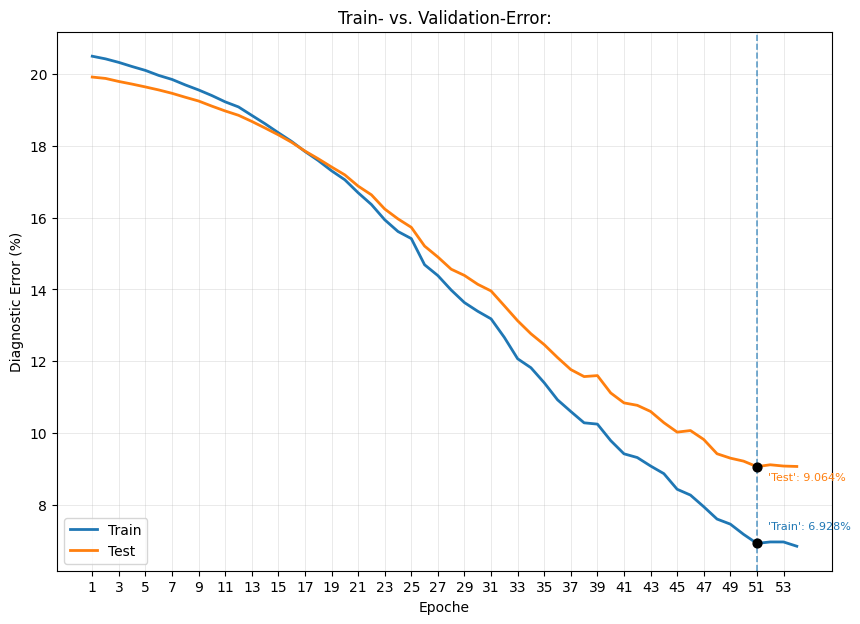

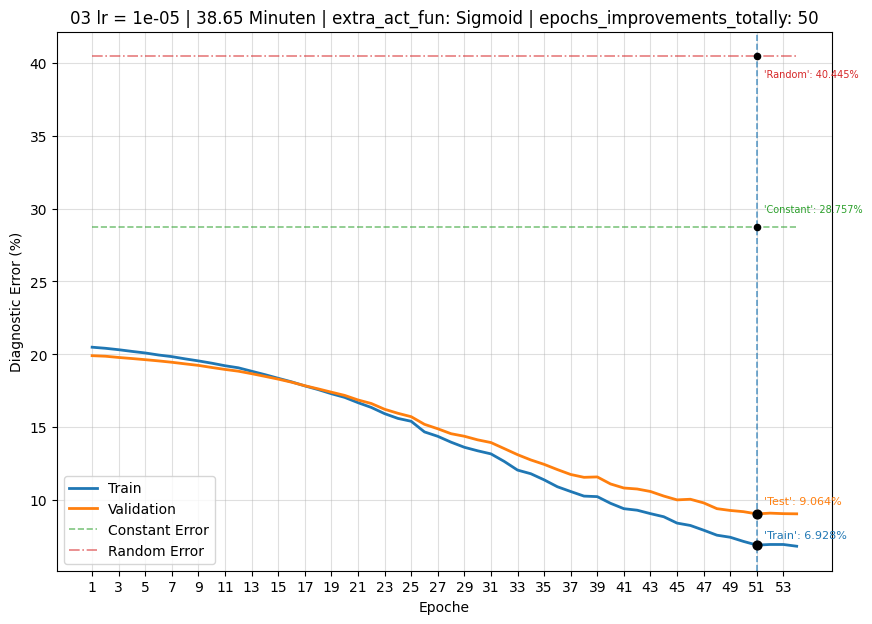

In [39]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_val_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(diag_val_error)}\t Diagonal-Test-Error-Min: {np.min(diag_val_error)}\t max_needed_epochs: {e+2}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")

# Session: 01
# if globals().get("bas_const_err") is None:
#     bas_const_err = 28.776

# if globals().get("bas_rand_err") is None:
#     bas_rand_err = 39.232


# Session: 03
if globals().get("bas_const_err") is None:
    bas_const_err = 28.7569

if globals().get("bas_rand_err") is None:
    bas_rand_err = 40.4452
    

# Curven:

# Minimum Test Error bestimmen
min_val_error = min(diag_val_error)
min_val_epoch = diag_val_error.index(min_val_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_val_epoch - 1]
val_at_min = diag_val_error[min_val_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
val_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_val_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Validation Error
plt.plot(epochs, diag_val_error, label="Test", linewidth=2, color=val_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=val_color,
    fontsize=8,
)


plt.title("Train- vs. Validation-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(np.arange(min(epochs), max(epochs), 2))

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Validation Error
plt.plot(
    epochs,
    diag_val_error,
    label="Validation",
    linewidth=2,
    color=val_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_val_epoch}")
print(f"Validation Error:      {val_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_val_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=val_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_val_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_val_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{session} "
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"epochs_improvements_totally: {e + 2}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(np.arange(min(epochs), max(epochs), 2))

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results/personal", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/personal/diag_error_{session}_{learning_rate}_{splits}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# a_random:
session: 03

 Diagonal-Train-Error: [20.4352 20.3631 20.2525 20.1281 20.0002 19.8658 19.7289 19.5797 19.4115
 19.2169 19.0042 18.7795 18.5182 18.2252 17.9004 17.5456 17.1554 16.7545
 16.3695 15.883  15.4362 14.9314 14.4695 13.9807 13.4792 12.9706 12.4919
 12.0043 11.5182 10.9498 10.454   9.9896  9.4663  9.0034  8.5544  8.1487
  7.6412  7.2773  6.8146  6.4476  6.121   5.747   5.525   5.2814  5.0038
  4.8136  4.6342  4.4462  4.2417  4.0963  3.9396  3.8188  3.699   3.5959
  3.4715  3.4623]

 Diagonal-Test-Error: [21.0439 20.9909 20.9212 20.8473 20.777  20.6962 20.6094 20.5139 20.3974
 20.2606 20.1026 19.9573 19.7783 19.5703 19.3118 19.0792 18.769  18.4602
 18.1457 17.763  17.4004 16.9247 16.5327 16.077  15.5758 15.1336 14.6571
 14.2573 13.7602 13.0633 12.6354 12.2504 11.6618 11.193  11.0116 10.5978
 10.3438 10.0364  9.7225  9.5061  9.3308  9.0693  9.0416  8.7628  8.6067
  8.6264  8.5733  8.4862  8.4427  8.55    8.2626  7.8324  7.7913  7.9252
  8.0852  8.1095]


 Diagonal-Train-Error-Max: 20.4352 	 Diagonal-Train-Error-Min: 3.4623	
 Diagonal-Test-Error-Max: 21.0439	 Diagonal-Test-Error-Min: 7.7913	 max_needed_epochs: 53



Minimum Test Error:
Epoch:           53
Validation Error:      7.7913%
Train Error:     3.6990%
Constant Error:  28.7569%
Random Error:    40.4452%

# ================================================================================================

b1) sequential:
session: 03 

 Diagonal-Train-Error: [20.4734 20.434  20.3619 20.2566 20.1315 20.0039 19.8758 19.7453 19.6044
 19.4389 19.2593 19.0579 18.8418 18.5957 18.327  18.024  17.68   17.3228
 16.9188 16.5125 16.0577 15.6182 15.1587 14.6237 14.0987 13.6284 13.1482
 12.6038 12.0918 11.5639 11.0552 10.5529 10.0504  9.5557  9.0125  8.525
  8.0616  7.6321  7.2532  6.8485  6.4839  6.1019  5.815   5.5005  5.2699
  4.9691  4.7712  4.5204  4.3534  4.157   4.009   3.8775  3.7054  3.5916
  3.4916  3.4304  3.2971  3.1581  3.0936  3.035   2.9875]

 Diagonal-Test-Error: [21.0789 21.0385 20.9773 20.9093 20.8291 20.7547 20.675  20.5876 20.4794
 20.3646 20.2192 20.071  19.9093 19.7336 19.5208 19.2781 19.0017 18.7326
 18.3673 17.9969 17.5618 17.1835 16.7869 16.2901 15.8112 15.2803 14.7942
 14.2626 13.7438 13.2294 12.8184 12.3282 11.7988 11.3553 10.9598 10.4758
 10.0988  9.6982  9.3955  9.1695  8.9442  8.6453  8.4306  8.323   8.3117
  8.2503  8.0054  7.8579  7.8058  7.6049  7.5505  7.4823  7.4169  7.3668
  7.3405  7.3579  7.3611  7.1191  7.1942  7.1688  7.128 ]


 Diagonal-Train-Error-Max: 20.4734 	 Diagonal-Train-Error-Min: 2.9875	
 Diagonal-Test-Error-Max: 21.0789	 Diagonal-Test-Error-Min: 7.1191	 max_needed_epochs: 57



Minimum Test Error:
Epoch:           58
Validation Error:      7.1191%
Train Error:     3.1581%
Constant Error:  28.7569%
Random Error:    40.4452%


# ===============================================================================================
d: two Videos
session: 03

 Diagonal-Train-Error: [20.4943 20.4205 20.3222 20.2067 20.099  19.9595 19.8481 19.695  19.555
 19.3986 19.2236 19.0826 18.847  18.6135 18.3637 18.1207 17.842  17.5889
 17.3044 17.0534 16.6926 16.365  15.9398 15.6131 15.416  14.6871 14.3851
 13.9832 13.6334 13.3919 13.1806 12.6639 12.0695 11.8195 11.4011 10.9265
 10.6008 10.2857 10.2497  9.7905  9.4225  9.3187  9.0837  8.8702  8.4353
  8.2733  7.9494  7.6057  7.4646  7.1788  6.9277  6.9685  6.968   6.8493]

 Diagonal-Test-Error: [19.9141 19.8758 19.7909 19.7179 19.6388 19.5554 19.4617 19.3517 19.247
 19.104  18.9699 18.8496 18.679  18.495  18.305  18.0962 17.8542 17.6387
 17.4103 17.1899 16.8777 16.6347 16.24   15.9645 15.7293 15.2073 14.9025
 14.5639 14.3895 14.1429 13.9575 13.5442 13.1274 12.7653 12.4627 12.1037
 11.7685 11.5732 11.6008 11.1178 10.8408 10.773  10.6023 10.2894 10.0266
 10.0704  9.8214  9.4245  9.3022  9.2181  9.0643  9.1174  9.0819  9.0703]


 Diagonal-Train-Error-Max: 20.4943 	 Diagonal-Train-Error-Min: 6.8493	
 Diagonal-Test-Error-Max: 19.9141	 Diagonal-Test-Error-Min: 9.0643	 max_needed_epochs: 50



Minimum Test Error:
Epoch:           51
Validation Error:      9.0643%
Train Error:     6.9277%
Constant Error:  28.7569%
Random Error:    40.4452%

# ---------- Evaluation ----------

In [27]:
# ---------- Evaluation ----------

saved_model_name = "models/personal/ResNet_best_model_lr(1e-05)_session(10).path"

last_saved_model = "models/personal/BEST-MODEL_RESNET_SIGMOID_session(03).path"

last_saved_model2 = "models/personal/BEST-MODEL_RESNET_SIGMOID_session(03+04).path"

checkpoint = torch.load(
    # saved_model_name,
    last_saved_model2,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()

print("Test:\n")
print(f"Session: {session2}")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error = {test_diag_pct:.4f}% "
    )

targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

Test:

Session: 04
MAE : 0.2541 	 RMSE: 0.2971 
Diagonal-Error %: 21.0104 %
test_diag_error = 21.0104% 


# Test: two Videos 03 + 04

session: 04

MAE : 0.2541 --|-- RMSE: 0.2971 

Diagonal-Error %: 21.0104 %

test_diag_error = 21.0104% 

# Test:

Session: 03

MAE : 0.0734 --|-- RMSE: 0.0949 

Diagonal-Error : 6.7092 %

test_diag_error = 6.7092% 

# Test:

MAE : 0.1341 	 RMSE: 0.1672 

Diagonal-Error %: 11.8241 %

test_diag_error=11.8241%

In [33]:
import pandas as pd


results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


results_df.to_csv(
    f"results/personal/predictions_{session}.csv",
    index=False
)

# Split:

    a) random: 70% train, 15% validation, 15% test
    b) sequential: first 70% train, next 15% validation, last 15% test

    c) first Video for train and validation, another Video for test

    d1) train and validation: after every 5 Second start movement with a random Startpoint
    d2) test: frames start 0.5 sec after every new Starting

    e) another Video with another camera und lighing-conditions


In [50]:
dirs = f"personalization/{session}"

csv_path = Path(dirs) / "norm_labels.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Fehlt: {csv_path.resolve()}")

df = pd.read_csv(csv_path)

dataset_size = len(df)

print(f"Gesamte Daten: {dataset_size}")


# ============================================================
# Vollständiges Dataset
# ============================================================

full_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
)

print(f"len(full_dataset): {len(full_dataset)}")


Gesamte Daten: 498


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 498/498 [00:05<00:00, 93.69it/s]

len(full_dataset): 498


In [58]:
train_size = int(dataset_size * 0.70)
validat_size = int(dataset_size * 0.15)

test_size = dataset_size - train_size - validat_size

print(
    f"\nTrain:      {train_size} | "
    f"Validation: {validat_size} | "
    f"Test:       {test_size} | "
    f"\n\nSumme:      {train_size + validat_size + test_size}"
)



Train:      348 | Validation: 74 | Test:       76 | 

Summe:      498


# Func: Create Splits

In [75]:

def create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42,
    original_fps=60,
    frame_step=5,
    reset_interval=5,
    exclusion_time=0.5,
    test_dataset=None
):

    dataset_size = len(full_dataset)


    # ============================================================
    # A: Random Split
    # ============================================================

    if split_type == "random":

        generator = torch.Generator().manual_seed(seed)

        train_dataset, validat_dataset, test_dataset = random_split(
            full_dataset,
            [train_size, validat_size, test_size],
            generator=generator
        )



    # ============================================================
    # B1: Sequential Split
    # ============================================================

    elif split_type == "sequential":

        train_indices = list(
            range(0, train_size)
        )

        validat_indices = list(
            range(
                train_size,
                train_size + validat_size
            )
        )

        test_indices = list(
            range(
                train_size + validat_size,
                dataset_size
            )
        )

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )



    # ============================================================
    # B2: Test first, then Train + Validation
    # ============================================================

    elif split_type == "test_first_random":

        generator = torch.Generator().manual_seed(seed)

        train_valid_size = train_size + validat_size

        train_valid_dataset, test_dataset = random_split(
            full_dataset,
            [train_valid_size, test_size],
            generator=generator
        )

        train_dataset, validat_dataset = random_split(
            train_valid_dataset,
            [train_size, validat_size],
            generator=generator
        )


    # ============================================================
    # C: Video 1 = Train + Validation
    #    Video 2 = Test
    # ============================================================

    elif split_type == "different_videos":

        if test_dataset is None:

            raise ValueError(
                "Für split_type='different_videos' "
                "muss test_dataset angegeben werden."
            )


        # --------------------------------------------------------
        # Train + Validation aus Video 1
        # --------------------------------------------------------

        train_valid_size = train_size + validat_size

        if train_valid_size > len(full_dataset):

            raise ValueError(
                "Train + Validation sind größer als "
                "das Train/Validation-Video."
            )


        generator = torch.Generator().manual_seed(seed)


        train_dataset, validat_dataset = random_split(
            full_dataset,
            [train_size, validat_size],
            generator=generator
        )


        # --------------------------------------------------------
        # Test = komplettes zweites Video
        # --------------------------------------------------------

        test_dataset = test_dataset


        print("\n" + "=" * 60)
        print("DIFFERENT-VIDEO SPLIT")
        print("=" * 60)

        print(
            f"Train/Validation Video: "
            f"{len(full_dataset)} Samples"
        )

        print(
            f"Test Video: "
            f"{len(test_dataset)} Samples"
        )

        print("\nSplit:")

        print(
            f"Train:       {len(train_dataset)}"
        )

        print(
            f"Validation:  {len(validat_dataset)}"
        )

        print(
            f"Test:        {len(test_dataset)}"
        )

        print("=" * 60)


    # ============================================================
    # D: Reset-aware Random Split
    # ============================================================

    elif split_type == "reset_aware":

        # --------------------------------------------------------
        # Tatsächliche Samplingrate nach Frame-Subsampling
        # --------------------------------------------------------

        effective_fps = original_fps / frame_step


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples pro Reset-Intervall
        # --------------------------------------------------------

        reset_samples = int(
            round(reset_interval * effective_fps)
        )


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples, die nach jedem Reset
        # ausgeschlossen werden
        # --------------------------------------------------------

        exclusion_samples = int(
            round(exclusion_time * effective_fps)
        )


        print("\n" + "=" * 60)
        print("RESET-AWARE SPLIT")
        print("=" * 60)

        print(f"Original FPS:          {original_fps}")
        print(f"Frame Step:            {frame_step}")
        print(f"Effektive FPS:         {effective_fps}")

        print(f"\nReset alle:            {reset_interval} s")
        print(f"Reset-Samples:         {reset_samples}")

        print(f"\nAusschlusszeit:        {exclusion_time} s")
        print(f"Ausschluss-Samples:    {exclusion_samples}")


        # --------------------------------------------------------
        # Gültige und ausgeschlossene Indizes bestimmen
        # --------------------------------------------------------

        valid_indices = []
        excluded_indices = []


        for idx in range(dataset_size):

            position_in_reset = idx % reset_samples


            # Erste 0.5 Sekunden nach jedem Reset
            if position_in_reset < exclusion_samples:

                excluded_indices.append(idx)

            else:

                valid_indices.append(idx)


        print(f"\nGesamte Samples:       {dataset_size}")
        print(f"Ausgeschlossen:        {len(excluded_indices)}")
        print(f"Verwendbar:            {len(valid_indices)}")


        # --------------------------------------------------------
        # Prüfen, ob genügend Daten vorhanden sind
        # --------------------------------------------------------

        required_size = (
            train_size
            + validat_size
            + test_size
        )


        if required_size > len(valid_indices):

            raise ValueError(
                "\nNicht genügend gültige Samples!\n"
                f"Benötigt:   {required_size}\n"
                f"Verfügbar: {len(valid_indices)}"
            )


        # --------------------------------------------------------
        # Gültige Daten zufällig mischen
        # --------------------------------------------------------

        generator = torch.Generator().manual_seed(seed)

        permutation = torch.randperm(
            len(valid_indices),
            generator=generator
        ).tolist()


        shuffled_indices = [
            valid_indices[i]
            for i in permutation
        ]


        # --------------------------------------------------------
        # Train
        # --------------------------------------------------------

        train_indices = shuffled_indices[
            :train_size
        ]


        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        validat_indices = shuffled_indices[
            train_size:
            train_size + validat_size
        ]


        # --------------------------------------------------------
        # Test
        # --------------------------------------------------------

        test_indices = shuffled_indices[
            train_size + validat_size:
            train_size + validat_size + test_size
        ]


        # --------------------------------------------------------
        # Subsets
        # --------------------------------------------------------

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )


        print("\nSplit:")
        print(f"Train:                 {len(train_dataset)}")
        print(f"Validation:            {len(validat_dataset)}")
        print(f"Test:                  {len(test_dataset)}")

        print("=" * 60)


    else:

        raise ValueError(
            f"Unbekannter split_type: {split_type}"
        )


    return (
        train_dataset,
        validat_dataset,
        test_dataset
    )

# a) random 

In [67]:

from torch.utils.data import DataLoader, Subset, random_split


# A1: Random
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42
)


print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



# B1: Sequential:

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



# B2: another Split but better: first Test next Train and Validation

all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")




# C: C: one Video for Train and Validation and another Video for Test
session1, session2 = str('03'), str('04') 

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size

print(f"Session1: {session1}-->{dataset_size}")
print(f"Train:      {train_size}")
print(f"Validation: {validat_size}")
print(f"Session2 Test: {session2}-->{len(test_dataset)}")


train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_dataset
)



# d: every 5 sec but after 0.5 sec:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)






Train:      348
Validation: 74
Test:       76


# b: Sequential:

In [ ]:
# B1:

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      348
Validation: 74
Test:       76


In [ ]:
# B2: another Split but better: first Test next Train and Validation



all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      348
Validation: 74
Test:       76


# C: one Video for Train and Validation and another Video for Test


In [76]:
session1, session2 = str('03'), str('04') 

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size

print(f"Session1: {session1}-->{dataset_size}")

print(f"Train:      {train_size}")
print(f"Validation: {validat_size}")

print(f"Session2 Test: {session2}-->{len(test_dataset)}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 548/548 [00:05<00:00, 108.46it/s]


Session1: 03-->482
Train:      385
Validation: 97
Session2 Test: 04-->548


In [77]:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_dataset
)



DIFFERENT-VIDEO SPLIT
Train/Validation Video: 482 Samples
Test Video: 548 Samples

Split:
Train:       385
Validation:  97
Test:        548


# d: every 5 sec first after 0.5 sec:

In [ ]:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)


# Test 

In [ ]:
def verify_dataset(
    dataset,
    csv_file,
    num_samples=20
):

    df = pd.read_csv(csv_file)

    print("=" * 60)
    print("DATASET VERIFICATION")
    print("=" * 60)

    print(f"CSV rows:      {len(df)}")
    print(f"Dataset size:  {len(dataset)}")

    assert len(df) == len(dataset), (
        "CSV und Dataset haben unterschiedliche Größen!"
    )

    num_samples = min(
        num_samples,
        len(dataset)
    )

    for idx in np.linspace(
        0,
        len(dataset) - 1,
        num_samples,
        dtype=int
    ):

        image, target = dataset[idx]

        csv_row = df.iloc[idx]

        csv_target = np.array(
            [
                csv_row["x"],
                csv_row["y"]
            ],
            dtype=np.float32
        )

        dataset_target = target.numpy()

        if not np.allclose(
            csv_target,
            dataset_target,
            atol=1e-6
        ):

            print(
                f"FEHLER bei Index {idx}"
            )

            print(
                "CSV:",
                csv_target
            )

            print(
                "Dataset:",
                dataset_target
            )

            return False

    print(
        f"\n✓ {num_samples} Samples erfolgreich überprüft."
    )

    return True


In [ ]:
verify_dataset(
    full_dataset,
    Path(dirs) / "norm_labels.csv",
    num_samples=20
)

In [ ]:
train_indices = set(train_dataset.indices)
validat_indices = set(validat_dataset.indices)
test_indices = set(test_dataset.indices)

print(
    "Train ∩ Validation:",
    len(train_indices & validat_indices)
)

print(
    "Train ∩ Test:",
    len(train_indices & test_indices)
)

print(
    "Validation ∩ Test:",
    len(validat_indices & test_indices)
)

# Results:
# Train ∩ Validation = 0
# Train ∩ Test       = 0
# Validation ∩ Test  = 0

In [ ]:
all_used = (
    train_indices
    | validat_indices
    | test_indices
)

print(
    "Anzahl verwendeter Samples:",
    len(all_used)
)

# Results: Bei deinem Reset-aware Split darf len(all_used) sogar kleiner als len(full_dataset) sein


In [19]:
# 01:
print(f"the results for Session: {session}")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01


Diagonal_train_error: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden
totll running-tiems (min): 5.19 Minuten



# the results for Session: 01
## only FC and without layer 4

Diagonal_train_error01: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error01: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden

totll running-tiems (min): 5.19 Minuten

In [24]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden
totll running-tiems (min): 4.88 Minuten



# the results for Session: 02

## only FC and without layer 4


Diagonal_train_error02: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error02: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden

totll running-tiems (min): 4.88 Minuten

In [29]:
# 03:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 03

only FC and without layer 4



Diagonal_train_error: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden
totll running-tiems (min): 5.62 Minuten



## the results for Session: 03

# only FC and without layer 4


Diagonal_train_error03: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error03: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden

totll running-tiems (min): 5.62 Minuten


In [51]:
# 04:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 04

only FC and without layer 4



Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden
totll running-tiems (min): 5.57 Minuten



# the results for Session: 04

## only FC and without layer 4


Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden

totll running-tiems (min): 5.57 Minuten


# ==================== Optimal =============================

In [56]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [19.4212 17.7688 16.9373 16.432  15.9572 15.5047 15.0849 14.7342 14.4432
 14.2265 14.0141 13.781  13.5563 13.348  13.1246 12.9289 12.7407 12.5674
 12.3858 12.2026]


Diagonal_test_error: [20.9319 17.7764 15.8419 14.8768 14.4095 14.1325 14.111  14.2164 14.2938
 14.2955 14.1694 13.848  13.4551 13.3329 13.005  12.886  12.8297 12.8031
 12.6214 12.4136]

 epochs: 20, 	 best_Error: 0.17555457971299732
 best_test_error: 12.4136%, 	max_test_Error: 20.9319%

totll running-tiems (s): 574.36 Sekunden
totll running-tiems (min): 9.57 Minuten



In [62]:
# 01:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

only FC and without layer 4



Diagonal_train_error: [15.3648 15.1013 15.1603 14.678  14.3885 14.2098 14.0774 13.9202 13.78
 13.657  13.5354 13.4318 13.3666 13.243  13.1577 13.0428 12.9579 12.9177
 12.7877 12.7263]


Diagonal_test_error: [16.7358 16.2906 16.3221 15.8886 15.7614 15.5712 15.2743 15.2488 15.1827
 15.0881 14.9273 14.8744 14.7402 14.6438 14.6689 14.6622 14.6104 14.5191
 14.4285 14.46  ]

 epochs: 20, 	 best_Error: 0.2040497107098068
 best_test_error: 14.4285%, 	max_test_Error: 16.7358%

totll running-tiems (s): 788.43 Sekunden
totll running-tiems (min): 13.14 Minuten



In [65]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 



Diagonal_train_error: [11.3647 10.2059  9.183   8.3242  7.5884  7.1476  6.4918  5.9299  5.6028
  5.1456  4.8113  4.533   4.2175  4.0028  3.7746  3.6418  3.4019  3.2304
  3.0697  3.1854]


Diagonal_test_error: [13.5827 12.993  12.4911 12.0546 11.8701 11.8472 11.48   10.8924 10.5413
 10.593  10.3502 10.3507 10.138  10.1412 10.1741 10.1195 10.0583  9.904
  9.8323  9.8302]

 epochs: 20, 	 best_Error: 0.1390205620095576
 best_test_error: 9.8302%, 	max_test_Error: 13.5827%

totll running-tiems (s): 1350.90 Sekunden
totll running-tiems (min): 22.51 Minuten



In [12]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 and Sigmoid \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 and Sigmoid 



Diagonal_train_error: [21.2963 20.4879 19.7773 19.1741 18.6438 18.159  17.7288 17.3245 16.9491
 16.5914 16.2423 15.8723 15.5279 15.1753 14.8057 14.446  14.0653 13.6825
 13.2886 12.9093]


Diagonal_test_error: [22.5788 21.8181 21.181  20.6503 20.1906 19.7427 19.3522 18.9706 18.6466
 18.3322 18.0399 17.7275 17.4513 17.1487 16.8487 16.573  16.2839 16.0158
 15.7229 15.4488]

 epochs: 20, 	 best_Error: 0.2184786646452124
 best_test_error: 15.4488%, 	max_test_Error: 22.5788%

totll running-tiems (s): 1438.26 Sekunden
totll running-tiems (min): 23.97 Minuten

